In [4149]:
#Imports:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re 
import datetime



In [4150]:
#Read the file and pick the specific sheet that I want 
excelSheet = pd.ExcelFile('/Users/preciousajilore/Documents/GitHub/torchmtlr/data/finalforAIpredictionmodeljuly25.xlsx')
print(excelSheet.sheet_names)


['Sheet1']


In [4151]:
df = pd.read_excel(
                  excelSheet,         # This is where you put the name of the excel file
                  sheet_name='Sheet1', # This is where you put the name of the sheet you want to read
                  engine='openpyxl')

In [4152]:
df.shape

(2066, 63)

In [4153]:
print(df.isna().sum().sort_values(ascending= False).head(30))

Unnamed: 62               2065
Unnamed: 61               2044
UAH ID                    2007
failure date              1964
signifcomp                1706
minorcomp                 1659
cath removal              1617
SP complication           1008
satisfaction               604
UTI  recurring             313
ER visits                  305
Persisting LUTS            301
Donor site                 295
Incontinence               252
Pain                       247
LUTS                       245
PVD                        245
Chordee                    244
Abx                        244
foley                      240
complication               230
UTI  Post                  221
Stricture                  219
Stricture intervention     207
claviangrade               179
fu                         176
erectilepost               170
LOS (days)                 128
 OR date                    95
Age: <50 = 0; >= 50= 1      93
dtype: int64


# Calculate the % of missing values in each column
missing_percent = df.isna().mean()

# Find columns to drop (over 50% missing)
cols_to_drop = missing_percent[missing_percent > 0.5].index

#print the columns that ww
# Drop them!
df = df.drop(columns=cols_to_drop)

print("Columns to be dropped:", list(cols_to_drop))
#print("New shape:", df.shape)

In [4154]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","")
df.columns

Index(['uahid', 'dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg',
       'age(attimeofsurgery)', 'age:<50=0;>=50=1', 'stxlocation', 'distal',
       'penile', 'stxetiology', 'stxlength', '#strictures', 'charlsons',
       'cormorbidity', 'diabetes', 'copd', 'smoker', 'bmi35+', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'abx',
       'erectilepre', 'uti', 'los(days)', 'spc', 'tissue', 'transection',
       'urethroplasty', 'cathremoval', 'cathdays', 'failure', 'patent', 'fu',
       'failuredate', 'datetofailureorfollowup', 'complication', 'clavianii+',
       'claviangrade', 'earlycomps', 'signifcomp', 'minorcomp', 'ervisits',
       'foley', 'spcomplication', 'erectilepost', 'pain', 'chordee', 'pvd',
       'donorsite', 'utipost', 'utirecurring', 'luts', 'persistingluts',
       'incontinence', 'stricture', 'strictureintervention', 'satisfaction',
       'unnamed:61', 'unnamed:62'],
      dtype='object')

In [4155]:
df.shape

(2066, 63)

In [4156]:
df = df.drop(columns=["uahid"])

In [4157]:
df[df["pvd"] == 'no FU']

,dob(yyyy-mm-dd),dateofsurgery,monthsurg,age(attimeofsurgery),age:<50=0;>=50=1,stxlocation,distal,penile,stxetiology,stxlength,...,utipost,utirecurring,luts,persistingluts,incontinence,stricture,strictureintervention,satisfaction,unnamed:61,unnamed:62
482,1979-07-28 00:00:00,2010-09-13,178.0,31.0,0,1,0.0,0.0,0,3,...,no FU,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
499,1941-09-05 00:00:00,2010-11-19,176.0,65.0,1,3,1.0,1.0,2,10,...,No,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
517,1992-07-01 00:00:00,2011-01-28,173.0,18.0,0,2,0.0,0.0,1,2,...,no FU,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
633,1930-12-27 00:00:00,2012-05-23,158.0,81.0,1,0,0.0,1.0,4,2,...,no FU,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
673,1940-08-31 00:00:00,2012-11-16,152.0,72.0,1,5,0.0,0.0,3,2,...,no,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
722,1966-05-24 00:00:00,2013-04-22,147.0,46.0,0,1,0.0,0.0,1,2,...,no FU,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
744,1960-07-04 00:00:00,2013-08-09,143.0,53.0,1,1,1.0,0.0,0,11,...,no FU,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
781,1992-12-28 00:00:00,2013-11-25,140.0,21.0,0,2,0.0,0.0,1,3,...,no FU,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
880,1962-09-02 00:00:00,2014-11-21,128.0,52.0,1,1,0.0,0.0,0,4,...,no FU,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN
944,2011-10-24 00:00:00,2015-04-24,123.0,4.0,0,0,0.0,1.0,4,4,...,no,no FU,no FU,no FU,no FU,no FU,no FU,no FU,NaN,NaN


In [4158]:
df["pvd"].unique()

array([0, nan, 1, 'no fu', 'no FU', 'NO FU', '-', 'no follow-up', 'No FU',
       'not reported', 'lost to f/u', 'no', 'yes', 'no Fu'], dtype=object)

In [4159]:
df["pvd"] = df["pvd"].replace("no",0)

In [4160]:
df["pvd"].unique()

array([0, nan, 1, 'no fu', 'no FU', 'NO FU', '-', 'no follow-up', 'No FU',
       'not reported', 'lost to f/u', 'yes', 'no Fu'], dtype=object)

In [4161]:
df["pvd"] = df["pvd"].replace("yes",1)

In [4162]:
df["pvd"] = df["pvd"].replace(
    to_replace=r".*\bno\b.*",  # any text containing the word "no"
    value=np.nan,
    regex=True
)

In [4163]:
df["pvd"] = df["pvd"].replace(
    to_replace=r".*\bFU\b.*",  # any text containing the word "no"
    value=np.nan,
    regex=True
)

In [4164]:
df["pvd"] = df["pvd"].replace({"not reported": np.nan, "lost to f/u": np.nan, "-":np.nan})

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/42593215.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["pvd"] = df["pvd"].replace({"not reported": np.nan, "lost to f/u": np.nan, "-":np.nan})


In [4165]:
df["pvd"].unique()

array([ 0., nan,  1.])

In [4166]:
df["pvd"] = df["pvd"].fillna(df["pvd"].median())


In [4167]:
df["pvd"].unique()

array([0., 1.])

In [4168]:
df.shape

(2066, 62)

In [4169]:
df["satisfaction"].unique()

array(['yes', 'no', nan, 'Yes', 'No', '?',
       'Patient cancelled second stage', 'no fu',
       'Dr. Rourke noted anastomotic inflammation and necrosis at 6 and 8 month cysto, but no note of further plan/intervention……',
       'no FU', 'no (CPPS)', 'NO FU', 'AUA Symptom score = 2',
       'NOTE: This patient had two separate strictures separated by a skip lesion.',
       'No records of patient care avaialble on netcare or healthquest',
       'no follow-up', 'not reported', 'second stage to follow',
       'wants to defer second stage', 'neutral', 'yes, very', 'unsure', 0,
       'lost to f/u', 'no record', 1, 'no 5-6 mo f/u'], dtype=object)

In [4170]:
df["satisfaction"] = df["satisfaction"].replace(
    to_replace=r".*\bno\b.*",  # any text containing the word "no"
    value=0,
    regex=True
)

In [4171]:
df["satisfaction"] = df["satisfaction"].replace({"?": np.nan})


In [4172]:
df["satisfaction"] = df["satisfaction"].replace({"Yes": 1,"yes":1 ,"AUA Symptom score = 2":1,"No": 0, "neutral": 0, "yes, very": 1})

df["satisfaction"] = df["satisfaction"].replace(
    to_replace=r".*(second stage|Note|Not|NOTE|unsure|not|Dr.).*",
    value=np.nan,
    regex=True
)

In [4173]:
df["satisfaction"].unique()

array([1, 0, nan, 'NO FU',
       'No records of patient care avaialble on netcare or healthquest',
       'lost to f/u'], dtype=object)

In [4174]:
def clean_sat(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v == '0' or 'no' in v or 'o' in v:
        return 0
    if v.startswith("lost") or "records" in v or "fu" in v or v == "?":
        return np.nan

    # 6. Default to nan if not caught above
    return np.nan

In [4175]:
df["satisfaction"] = df["satisfaction"].apply(clean_sat)


In [4176]:
df["satisfaction"].unique()

array([ 1.,  0., nan])

In [4177]:
df["satisfaction"] = df["satisfaction"].fillna(df["satisfaction"].median())


In [4178]:
df["satisfaction"].unique()

array([1., 0.])

In [4179]:
df["cysto"]= df["cysto"].replace({"none": 0, 5:3, 3:2, 2:1})
df["cysto"].unique()

#Prior Endoscopic procedures (None=0, One-two=1, Three-Five=2, Greater than 5=3) 

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/1765746698.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["cysto"]= df["cysto"].replace({"none": 0, 5:3, 3:2, 2:1})


array([ 1.,  0.,  2., nan,  3.])

In [4180]:
df["cysto"].unique()


array([ 1.,  0.,  2., nan,  3.])

In [4181]:
df["cysto"] = df["cysto"].fillna(df["cysto"].median())


In [4182]:
df["cysto"].unique()


array([1., 0., 2., 3.])

In [4183]:
#Hot encoding for the cysto column
#Prior Endoscopic procedures (None=0, One-two=1, Three-Five=2, Greater than 5=3) 
cysto_dummies = pd.get_dummies(df["cysto"], prefix="cysto", dummy_na=False)
df = pd.concat([df, cysto_dummies], axis=1)

In [4184]:
df.columns

Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'age:<50=0;>=50=1', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto',
       'open', 'ordate', 'urine', 'abx', 'erectilepre', 'uti', 'los(days)',
       'spc', 'tissue', 'transection', 'urethroplasty', 'cathremoval',
       'cathdays', 'failure', 'patent', 'fu', 'failuredate',
       'datetofailureorfollowup', 'complication', 'clavianii+', 'claviangrade',
       'earlycomps', 'signifcomp', 'minorcomp', 'ervisits', 'foley',
       'spcomplication', 'erectilepost', 'pain', 'chordee', 'pvd', 'donorsite',
       'utipost', 'utirecurring', 'luts', 'persistingluts', 'incontinence',
       'stricture', 'strictureintervention', 'satisfaction', 'unnamed:61',
       'unnamed:62', 'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0'],
      dtype='object')

In [4185]:
def clean_utirecur(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v =="no" or v == '0' or 'o' in v:
        return 0
    if "fu" in v or "reported" in v or v == "-" or "lost" in v or "follow-up" in v:
        return np.nan


    # 6. Default to nan if not caught above
    return np.nan

In [4186]:
df["utirecurring"].unique()

array(['no', nan, 'yes', 'No', 'Yes', 0, 'no fu', 'no FU', 'NO', 'NO FU',
       '-', 'no follow-up', 'yes (possible UTI, GrHem)',
       'yes (x1 pseudomonas)', 'No FU', 'o', 'not reported', 'yes @4m',
       'lost to f/u', 1, 'no Fu'], dtype=object)

In [4187]:
df["utirecurring"] = df["utirecurring"].apply(clean_utirecur)

In [4188]:
df["utirecurring"].unique()

array([ 0., nan,  1.])

In [4189]:
df["utirecurring"] = df["utirecurring"].fillna(df["satisfaction"].median())

In [4190]:
df["utirecurring"].unique()
#UTI - 5-6mos (>1 occurring  yes/no)

array([0., 1.])

In [4191]:
def clean_per(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v or v ==" minimal":
        return 1
    # 3. Obvious no answers
    if v == '0' or v =="no" or 'o' in v or v == 0:
        return 0
    if v == "-" or v == "not reported" or "fu" in v:
        return np.nan


    # 6. Default to nan if not caught above
    return np.nan

In [4192]:
df["persistingluts"].unique()


array(['no', nan, 'yes', 'yes-obst. s/s at 2.5 mos started on flomax',
       'yes-mild sensation of incomplerte emptying', 'No', 'Yes',
       'frequency and nocturia (rads cystitis)', 0,
       'yes (DFOS, hesitency)', 'Yes, Urgency',
       'Yes, urgency, freq, decreased force of stream',
       'Yes, urgency and frequency', 'yes, urgency', 'Yes, urgency',
       'Yes, hesitency', 'Yes, dysuria (present pre-op/chronic)',
       'Yes, DFOS', 'yes, frequency', 'Yes (minimal)', 'no fu',
       'Yes (frequency)', 'no FU', 'NO', 'NO FU',
       'Yes (Mild) - After 6 months', 'Yes (Mild)', 'Yes - Minimum',
       'yes  ', 'Yes (Minimum)', 'yes (urgency from rads cystitis)',
       'Yes (hesitancy)', 'yes (urgency)', 'yes (recurring, mild)',
       'yes (chronic retention/urine remaining in bladder post-void)',
       'yes (mild)',
       'no (pre-surgery LUTS and residual post void urine retention issues resolved)',
       'yes; mild', '-', 'no follow-up', 'yes - mild ',
       'yes - dys

In [4193]:
df["persistingluts"] = df["persistingluts"].apply(clean_per)

In [4194]:
df["persistingluts"].unique()


array([ 0., nan,  1.])

In [4195]:
df["persistingluts"] = df["persistingluts"].fillna(df["persistingluts"].median())

In [4196]:
df["persistingluts"].unique()

array([0., 1.])

In [4197]:
df.shape

(2066, 66)

In [4198]:
df["ervisits"].unique()

array(['yes', 'No', 'no',
       'yes(hematoma,celulitis of the penis,urethrocutaneous fistula)',
       'no (yes for CP/GERD at just under 90d)', 'Yes',
       'Yes - post op wound pain, uncomplicated, no infection',
       'yes - UTI', 'Yes, pre-op', 'No (only pre-op x 1)',
       'yes - wound infection', nan, 'Yes, for irrigation of foley',
       'Yes (for wound dehissance and perineal pain 13 days post-op)',
       'Yes (pre-op, not post op)', 'Yes (for donor site pain)',
       'Yes (for dehiscence)', 'Yes (gross hematuria after 5 mo cysto)',
       'Yes - UC fistula from SPC site', 'Yes (for wound infection)',
       'Yes - Urosepsis', 'Yes (right epididymitis)',
       'Yes - UTI; thigh abscess', 'yes - retention',
       'Yes (hematuria/retention)', 'Unknown', 'no FU',
       'yes (perioperatively)', 'yes (not tolerating cipro)',
       'ER visit before BUR', 'yes (infection)', 'no fu', 'lost to f/u',
       0, 1], dtype=object)

In [4199]:
def clean_er(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v.startswith('no') or v == '0' or 'no' in v or 'o' in v:
        return 0


    # 6. Default to nan if not caught above
    return np.nan

In [4200]:
df["ervisits"] = df["ervisits"].apply(clean_er)
print(df["ervisits"].unique())

[ 1.  0. nan]


In [4201]:
df["ervisits"] = df["ervisits"].fillna(df["ervisits"].median())
print(df["ervisits"].unique())

[1. 0.]


In [4202]:
print(df["donorsite"].unique())

[0 nan 1 'no fu' 'no FU' 'NO FU' '-' 'no follow-up' 'No FU' 'not reported'
 'o' 'lost to f/u' 'no' 'no Fu']


In [4203]:
def clean_donor(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v == "no" or v == "o":
        return 0
    if v.startswith('lost') or v == "-" or "fu" in v or v == "not_reported":
        return np.nan



    # 6. Default to nan if not caught above
    return np.nan

In [4204]:
df["donorsite"] = df["donorsite"].apply(clean_donor)
df["donorsite"].unique()

array([nan,  1.,  0.])

In [4205]:
df["donorsite"] = df["donorsite"].fillna(df["donorsite"].median())
print(df["donorsite"].unique())

[1. 0.]


In [4206]:
df["incontinence"].unique()


array([0, nan, 1, 'no fu', 'no FU', 'NO FU', '-', 'no follow-up', 'No FU',
       'not reported', 'no', 'lost to f/u', 'no Fu'], dtype=object)

In [4207]:
def clean_in(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v == "no":
        return 0
    if v.startswith('lost') or v == "-" or "fu" in v or "follow-up" in v or "not reported" in v:
        return np.nan



    # 6. Default to nan if not caught above
    return np.nan

In [4208]:
df["incontinence"] = df["incontinence"].apply(clean_in)
df["incontinence"].unique()

array([nan,  1.,  0.])

In [4209]:
df["incontinence"] = df["incontinence"].fillna(df["incontinence"].median())
print(df["incontinence"].unique())

[1. 0.]


In [4210]:
print(df["luts"].unique())

[0 nan 1 'no fu' 'no FU' 'NO FU' '-' 'no follow-up' 'No FU' 'not reported'
 'lost to f/u' 'not yet 6 mo' 'yes' 'no' 'no Fu']


In [4211]:
def clean_luts(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v == "no":
        return 0
    if v.startswith('lost') or v == "-" or "fu" in v or "follow-up" in v or "not reported" in v:
        return np.nan



    # 6. Default to nan if not caught above
    return np.nan

In [4212]:
df["luts"] = df["luts"].apply(clean_luts)
df["luts"].unique()

array([nan,  1.,  0.])

In [4213]:
df["luts"] = df["luts"].fillna(df["luts"].median())

In [4214]:
df["luts"].unique()

array([1., 0.])

In [4215]:
df["pain"].unique()

array([0, nan, 1, 'no fu', 'no FU', 'NO FU', 'n.a', '-', 'no follow-up',
       'No FU', 'not reported', 'lost to f/u', 'no', 'no Fu'],
      dtype=object)

In [4216]:
def clean_pain(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v == "no":
        return 0
    if v.startswith('lost') or v == "-" or "fu" in v or "follow-up" in v or "not reported" in v or "n.a":
        return np.nan



    # 6. Default to nan if not caught above
    return np.nan

In [4217]:
df["pain"] = df["pain"].apply(clean_pain)
df["pain"].unique()

array([nan,  1.,  0.])

In [4218]:
df["pain"] = df["pain"].fillna(df["pain"].median())

In [4219]:

df["pain"].unique()

array([1., 0.])

In [4220]:
df.shape

(2066, 66)

In [4221]:
df["pain"].isna().sum()

0

In [4222]:
print(df.isna().sum().sort_values(ascending= False).head(30))

unnamed:62                 2065
unnamed:61                 2044
failuredate                1964
signifcomp                 1706
minorcomp                  1659
cathremoval                1617
spcomplication             1008
chordee                     244
abx                         244
foley                       240
complication                230
utipost                     221
stricture                   219
strictureintervention       207
claviangrade                179
fu                          176
erectilepost                170
los(days)                   128
ordate                       95
monthsurg                    93
age:<50=0;>=50=1             93
cormorbidity                 90
cathdays                     47
#prevprocedures              33
erectilepre                  19
earlycomps                   12
uti                           8
clavianii+                    5
datetofailureorfollowup       5
smoker                        5
dtype: int64


df = df.drop(columns=["spcomplication"])
print(df.isna().sum().sort_values(ascending= False).head(30))

In [4223]:
df["chordee"].unique()

array([0, nan, 1, 'no fu', 'no FU', 'NO FU', '-', 'no follow-up', 'No FU',
       'no', 'not reported', 'lost to f/u', 'no Fu'], dtype=object)

In [4224]:
def clean_chordee(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v == "no":
        return 0
    if v.startswith('lost') or v == "-" or "fu" in v or "follow-up" in v or "not reported" in v or "n.a":
        return np.nan



    # 6. Default to nan if not caught above
    return np.nan

In [4225]:
df["chordee"] = df["chordee"].apply(clean_chordee)
df["chordee"].unique()

array([nan,  1.,  0.])

In [4226]:
df["chordee"] = df["chordee"].fillna(df["chordee"].median())

In [4227]:
df["chordee"].unique()

array([1., 0.])

In [4228]:
df["foley"].unique()

array(['no', 'Yes, fell out(day 1), replaced', 'No',
       'yes, fell out, left SP to drainage',
       'Yes, failed voiding trial, reinserted, Flomax', '?no', 'yes',
       'Yes', 'There was no foley inserted', nan, '?', 'Np', 'no FU',
       'no fu', 'lost to f/u', 0, 1], dtype=object)

In [4229]:
def clean_foley(val):
    if pd.isna(val):
        return np.nan
    v = str(val).lower().strip()

    if v.startswith('yes') or v.startswith('y;') or v == '1' or 'yes' in v:
        return 1
    # 3. Obvious no answers
    if v == "no" or v=="?no":
        return 0
    if v.startswith('lost') or v == "-" or "fu" in v or "follow-up" in v or "not reported" in v or "n.a" or "there was no foley inserted":
        return np.nan



    # 6. Default to nan if not caught above
    return np.nan

In [4230]:
df["foley"] = df["foley"].apply(clean_foley)
df["foley"].unique()

array([ 0.,  1., nan])

In [4231]:
df["foley"] = df["foley"].fillna(df["foley"].median())
df["foley"].unique()

array([0., 1.])

In [4232]:
df["complication"].unique()

array([1, 0, 'Er visit- check netcare', nan, 'not yet 3 months',
       'follow-up not in chart', 'Patient delayed til Fall',
       'patient no show', 'not updatd', 'no followup', 'no FU', 9, '0`',
       'no fu', 'lost to f/u'], dtype=object)

In [4233]:
def clean_comp(val):
    if pd.isna(val):
        return np.nan

    v = str(val).lower().strip()

    # 1. Obvious yes answers
    if v.startswith("yes") or v.startswith("y;") or v == "1" or "yes" in v or "er" in v or v == "9":
        return 1

    # 2. Obvious no answers
    if v.startswith("no") or v == "0" or v == "0`" or v == "?no":
        return 0

    # 3. Missing or follow-up related → NaN
    if (
        v.startswith("lost")
        or v == "-"
        or "fu" in v
        or "follow-up" in v
        or "not reported" in v
        or "n.a" in v
        or "follow-up not in chart" in v
        or "delayed" in v
        or "not" in v
    ):
        return np.nan

    # 4. Default → NaN
    return np.nan

In [4234]:
df["complication"] = df["complication"].apply(clean_comp)
df["complication"].unique()


array([ 1.,  0., nan])

In [4235]:
df["complication"] = df["complication"].fillna(df["complication"].median())
df["complication"].unique()

array([1., 0.])

In [4236]:
df.shape

(2066, 66)

In [4237]:
df["stricture"].unique()

array([0, 1, 'no fu', 'no FU', 'NO FU', nan, '-', 'no follow-up', 'No FU',
       'not reported', 'lost to f/u'], dtype=object)

In [4238]:
def clean_stricture(val):
    if pd.isna(val):
        return np.nan

    v = str(val).lower().strip()

    # 1. Obvious yes answers
    if v.startswith("yes") or v.startswith("y;") or v == "1" or "yes" in v or "er" in v or v == "9":
        return 1

    # 2. Obvious no answers
    if v.startswith("no") or v == "0" or v == "0`" or v == "?no":
        return 0

    # 3. Missing or follow-up related → NaN
    if (
        v.startswith("lost")
        or v == "-"
        or "fu" in v
        or "follow-up" in v
        or "not reported" in v
        or "n.a" in v
        or "follow-up not in chart" in v
        or "delayed" in v
        or "not" in v
        or "nan" in v
    ):
        return np.nan

    # 4. Default → NaN
    return np.nan

In [4239]:
df["stricture"] = df["stricture"].apply(clean_stricture)
df["stricture"].unique()


array([ 0.,  1., nan])

In [4240]:
df["stricture"] = df["stricture"].fillna(df["stricture"].median())
df["stricture"].unique()

array([0., 1.])

In [4241]:
df["abx"].unique()

array(['yes', 'Yes', nan, '?', 'No', 'no records', 'not available', 'YES',
       'No records', 'yes (not mentioned)', 'no record', 'yes ', ' yes',
       'no', 1], dtype=object)

In [4242]:
def clean_abx(val):
    if pd.isna(val):
        return np.nan

    v = str(val).lower().strip()

    # 1. Obvious yes answers
    if v.startswith("yes") or v.startswith("y;") or v == "1" or "yes" in v:
        return 1

    # 2. Obvious no answers
    if v == "0" or v == "?no" or "no" in v:
        return 0

    # 3. Missing or follow-up related → NaN
    if (
        v.startswith("lost")
        or v == "-"
        or "fu" in v
        or "follow-up" in v
        or "not available" in v
        or "n.a" in v
        or "no record" in v
        or "delayed" in v
        or "not" in v
        or "nan" in v
        or "?"
    ):
        return np.nan

    # 4. Default → NaN
    return np.nan

In [4243]:
df["abx"] = df["abx"].apply(clean_abx)

In [4244]:
df["abx"].unique()

array([ 1., nan,  0.])

In [4245]:
df["abx"] = df["abx"].fillna(df["abx"].median())
df["abx"].unique()

array([1., 0.])

In [4246]:
df.shape

(2066, 66)

In [4247]:
print(df.isna().sum().sort_values(ascending= False).head(30))

unnamed:62                 2065
unnamed:61                 2044
failuredate                1964
signifcomp                 1706
minorcomp                  1659
cathremoval                1617
spcomplication             1008
utipost                     221
strictureintervention       207
claviangrade                179
fu                          176
erectilepost                170
los(days)                   128
ordate                       95
age:<50=0;>=50=1             93
monthsurg                    93
cormorbidity                 90
cathdays                     47
#prevprocedures              33
erectilepre                  19
earlycomps                   12
uti                           8
smoker                        5
datetofailureorfollowup       5
clavianii+                    5
diabetes                      4
bmi35+                        4
copd                          4
open                          3
failure                       2
dtype: int64


In [4248]:
df["utipost"].unique()

array([0, 'no', 1, nan, 'yes', 'No', 'Yes', 'Yes (prostatitis)',
       'Yes x 3', 'Yes (E. coli)', 'Yes (E. coli/ESBL)', 'no fu', 'no FU',
       'NO', 'Yes?', '-', 'no follow-up', 'NO FU', 'not reported',
       'lost to f/u'], dtype=object)

In [4249]:
def clean_uitpost(val):
    if pd.isna(val):
        return np.nan

    v = str(val).lower().strip()

    # 1. Obvious yes answers
    if v.startswith("yes") or v.startswith("y;") or v == "1" or "yes" in v:
        return 1

    # 2. Obvious no answers
    if v == "0" or v == "?no" or v == "no":
        return 0

    # 3. Missing or follow-up related → NaN
    if (
        v.startswith("lost")
        or v == "-"
        or "fu" in v
        or "follow-up" in v
        or "not reported" in v
        or "n.a" in v
        or "no record" in v
        or "delayed" in v
        or "not" in v
        or "nan" in v
        or "?"
    ):
        return np.nan

    # 4. Default → NaN
    return np.nan

In [4250]:
df["utipost"] = df["utipost"].apply(clean_uitpost)
df["utipost"].unique()

array([ 0.,  1., nan])

In [4251]:
df["utipost"] = df["utipost"].fillna(df["utipost"].median())
df["utipost"].unique()

array([0., 1.])

In [4252]:
df["strictureintervention"].unique()

array([0, 'no', 'yes', 'Yes, (DVIU)', 'No',
       'Yes dilated at 6 months post revision and contiued dilations until a successful repeat urethroplasty done in July 2011 outside the dates of this database currently',
       'yes (repeat urethroplasty in the form of perineal urethrostomy in 2009)',
       'yes (DVIU x2)',
       'Yes, occurred at site distal to reconstruction, dilated with scope',
       'Yes recurrent meatal stenosis req dilation to 18 Fr',
       'Yes DVIU at 6 months',
       'Yes but he has elected not to do anything', 1,
       'No, but he previously had an EPA by Dr. Rourke that resulted in UC fistula and restricturing… thus he required this procedure. I could not find his EPA procedure in this database',
       'Yes, required staged procedure after this failed PIF',
       'Yes, but proximal to graft', 'yes, DVIU', 'Yes', 'Yes (laser)',
       'Yes (DVIU)', 'Yes (DVIU once per year for 3 years)',
       'yes (dilated)', 'Yes (meatal stenosis, meatotomy and YV fl

In [4253]:
def clean_strictint(val):
    if pd.isna(val):
        return np.nan

    v = str(val).lower().strip()

    # 1. Obvious yes answers
    if v.startswith("yes") or v.startswith("y;") or v == "1" or "yes" in v or "mild" in v:
        return 1

    # 2. Obvious no answers
    if v == "0" or v == "?no" or v == "no":
        return 0

    # 3. Missing or follow-up related → NaN
    if (
        v.startswith("lost")
        or v == "-"
        or "fu" in v
        or "follow-up" in v
        or "not reported" in v
        or "n.a" in v
        or "no record" in v
        or "delayed" in v
        or "not" in v
        or "nan" in v
        or "?"
    ):
        return np.nan

    # 4. Default → NaN
    return np.nan

In [4254]:
df["strictureintervention"] = df["strictureintervention"].apply(clean_strictint)
df["strictureintervention"].unique()

array([ 0.,  1., nan])

In [4255]:
df["strictureintervention"] = df["strictureintervention"].fillna(df["strictureintervention"].median())
df["strictureintervention"].unique()

array([0., 1.])

In [4256]:
df["claviangrade"].unique()

array([ 2.,  0.,  4.,  1.,  3., nan,  5.,  6.])

In [4257]:
df["claviangrade"] = df["claviangrade"].fillna(df["claviangrade"].median())
df["claviangrade"].unique()

array([2., 0., 4., 1., 3., 5., 6.])

In [4258]:
#90d Clavien Grade– Clavien I-1, Clavien II-2, Clavien IIIa=3, Clavien IIIb=4, Clavien IVa=5, Clavien IVb=6, Clavien V=7)
#Hot encoding for the claviangrade column

clav_dummies = pd.get_dummies(df["claviangrade"], prefix="claviangrade", dummy_na=False)
df = pd.concat([df, clav_dummies], axis=1)

In [4259]:
df.columns

Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'age:<50=0;>=50=1', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto',
       'open', 'ordate', 'urine', 'abx', 'erectilepre', 'uti', 'los(days)',
       'spc', 'tissue', 'transection', 'urethroplasty', 'cathremoval',
       'cathdays', 'failure', 'patent', 'fu', 'failuredate',
       'datetofailureorfollowup', 'complication', 'clavianii+', 'claviangrade',
       'earlycomps', 'signifcomp', 'minorcomp', 'ervisits', 'foley',
       'spcomplication', 'erectilepost', 'pain', 'chordee', 'pvd', 'donorsite',
       'utipost', 'utirecurring', 'luts', 'persistingluts', 'incontinence',
       'stricture', 'strictureintervention', 'satisfaction', 'unnamed:61',
       'unnamed:62', 'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0',
       'claviangrade_0.0',

In [4260]:
df["erectilepost"].unique()

array([1, 0, nan, 2, '?0 (gender reassign phalloplasty)', '1(SCI C#6)', 3,
       4, '-', 'pre-op dysfunction',
       '1 (no comment was made - assumed same)',
       '1 (no comments on changes but significant ED before/after)',
       '2 (comparing "satisifactory" pre-op with "significant ED" post op',
       'not mentioned',
       '2 ( significant ED but unclear whether worse post-op)',
       '1 (severe pre-op ED, but no comments post-op)',
       'no comments on function', 'no follow-up',
       '1 responding to cialis', 'not reported', 'no FU', 'no',
       'No F/u to date'], dtype=object)

ED 0=no, 1=yes no change fr preop, 2=ED worse postop 3=ejac dys

In [4261]:
 

def clean_ed(val):
    if pd.isna(val):
        return np.nan

    v = str(val).lower().strip()

    #  Explicit numeric values
    if v in ["0", "1", "2", "3", "4"]:
        return int(v)

    #  Starts with a valid numeric code (e.g., "1 (severe pre-op ED...)")
    if v.startswith("0"):
        return 0
    if v.startswith("1"):
        return 1
    if v.startswith("2"):
        return 2
    if v.startswith("3"):
        return 3
    if v.startswith("4"):
        return 4

    # Obvious no
    if v == "no" or v == "?0":
        return 0

    #Missing / not mentioned / unclear → NaN
    if (
        "not mentioned" in v
        or "not reported" in v
        or "no comments" in v
        or "pre-op dysfunction" in v
        or v == "-"
        or "fu" in v
        or "follow-up" in v
        or "f/u" in v
    ):
        return np.nan

    # Default to NaN if not caught
    return np.nan


In [4262]:
df["erectilepost"] = df["erectilepost"].apply(clean_ed)
df["erectilepost"].unique()

array([ 1.,  0., nan,  2.,  3.,  4.])

In [4263]:
df["erectilepost"] = df["erectilepost"].fillna(df["erectilepost"].median())

In [4264]:
df["erectilepost"].unique()

array([1., 0., 2., 3., 4.])

In [4265]:
#ED 0=no, 1=yes no change fr preop, 2=ED worse postop 3=ejac dys
ed_dummies = pd.get_dummies(df["erectilepost"], prefix="erectilepost", dummy_na=False)
df = pd.concat([df, ed_dummies], axis=1)

In [4266]:
df["los(days)"].unique()

array([2, 5, 4, 6, 3, 7, nan, 31, '?', 18, 1, 0, 8, '7 (O2 requirements',
       'no record', 11, 10, 23], dtype=object)

In [4267]:
df["los(days)"] = df["los(days)"].replace({"7 (O2 requirements": 7, "no record": np.nan, "?": np.nan})
df["los(days)"].unique()
#array([2, 5, 4, 6, 3, 7, nan, 31, 18, 1, 0, 8, '7 (O2 requirements', 11,
     #  10, 23], dtype=object)#

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/4067302404.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["los(days)"] = df["los(days)"].replace({"7 (O2 requirements": 7, "no record": np.nan, "?": np.nan})


array([ 2.,  5.,  4.,  6.,  3.,  7., nan, 31., 18.,  1.,  0.,  8., 11.,
       10., 23.])

In [4268]:
df["los(days)"] = df["los(days)"].fillna(df["los(days)"].median()
)


df["los(days)"].unique()


array([ 2.,  5.,  4.,  6.,  3.,  7., 31., 18.,  1.,  0.,  8., 11., 10.,
       23.])

In [4269]:
df = df.drop(columns=["age:<50=0;>=50=1"])
df.columns

Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength',
       '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd',
       'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open',
       'ordate', 'urine', 'abx', 'erectilepre', 'uti', 'los(days)', 'spc',
       'tissue', 'transection', 'urethroplasty', 'cathremoval', 'cathdays',
       'failure', 'patent', 'fu', 'failuredate', 'datetofailureorfollowup',
       'complication', 'clavianii+', 'claviangrade', 'earlycomps',
       'signifcomp', 'minorcomp', 'ervisits', 'foley', 'spcomplication',
       'erectilepost', 'pain', 'chordee', 'pvd', 'donorsite', 'utipost',
       'utirecurring', 'luts', 'persistingluts', 'incontinence', 'stricture',
       'strictureintervention', 'satisfaction', 'unnamed:61', 'unnamed:62',
       'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0', 'claviangrade_0.0',
       'claviangrade_1.0',

In [4270]:
df["cormorbidity"].unique()

array([ 1.,  0., nan])

In [4271]:
df["cormorbidity"] = df["cormorbidity"].fillna(df["cormorbidity"].median())
df["cormorbidity"].unique()

array([1., 0.])

In [4272]:
df["#prevprocedures"].unique()

array([  3.,   5.,   0.,  10.,   2.,   1.,   4.,   7.,   6.,  20.,  12.,
        11.,  nan,   8.,  13.,  50.,  40.,  15.,  22., 100.,   9.,  14.,
        18.])

In [4273]:
df["#prevprocedures"] = df["#prevprocedures"].fillna(df["#prevprocedures"].median())
df["#prevprocedures"].unique()

array([  3.,   5.,   0.,  10.,   2.,   1.,   4.,   7.,   6.,  20.,  12.,
        11.,   8.,  13.,  50.,  40.,  15.,  22., 100.,   9.,  14.,  18.])

In [4274]:
df["erectilepre"].unique()

array([1, 0, nan, 'Yes?', 'Yes (Mild)', 'Yes (Moderate)',
       'no; did have occasional ejaculation pain pre-operatively. Also LUTS.',
       'yes; mild', 'yes - from pelvic fracture',
       'no (but pain with erections and ejaculation)',
       'no - but suffers from chordee', 'not sexually active',
       'no (no activity)', 'yes - mild', 'no (premature ejac?)',
       'yes (mild)', 'yes - No EF', 'yes - based on survey', 'no records',
       'no (ejac weak likely due to stricture)',
       'no (based on survey - yes)',
       '? (no sexual activity and low ratings on surveys ', 'yes - pain',
       'no (feeling of minor ejac resistance)',
       'yes (severe long duration)', 'probably but not mentioned', 'no ',
       'yes (0/10)', 'yes (1/10)', 'Yes (5/10)', 'yes (3/10)',
       'yes (2/10)', 'yes (7/10)', '1-mild?'], dtype=object)

In [4275]:
 

def clean_erpre(val):
    if pd.isna(val):
        return np.nan

    v = str(val).lower().strip()

    

    # 1. Obvious yes answers
    if v.startswith("yes") or v.startswith("y;") or v == "1" or "yes" in v or "mild" in v or "probably" in v or v =="1-mild":
        return 1

    # 2. Obvious no answers
    if v == "0" or v == "?no" or v == "no" or v == "not sexually active":
        return 0

    #Missing / not mentioned / unclear → NaN
    if (
        "not mentioned" in v
        or "no records" in v
        or v.startswith("?") 
        or "pre-op dysfunction" in v
        or v == "-"
        or "fu" in v
        or "follow-up" in v
        or "f/u" in v
    ):
        return np.nan

    # Default to NaN if not caught
    return np.nan


In [4276]:
df["erectilepre"] = df["erectilepre"].apply(clean_erpre)


df["erectilepre"].unique()


array([ 1.,  0., nan])

In [4277]:
df["erectilepre"] = df["erectilepre"].fillna(df["erectilepre"].median()
)
df["erectilepre"].unique()




array([1., 0.])

In [4278]:
df["earlycomps"].unique()


array([0, 2, 1, 'No', nan], dtype=object)

In [4279]:
df["erectilepre"] = df["erectilepre"].replace({"No": 0})

df["erectilepre"]= df["erectilepre"].fillna(df["erectilepre"].median()
)
df["erectilepre"].unique()



array([1., 0.])

In [4280]:
df["uti"].unique()


array([0, 1, nan, 'unknown', '?', 'Not done',
       '0-  but had acute urinary retention and needed suprapubic catheter a month before surgery'],
      dtype=object)

In [4281]:
df["uti"] = df["uti"].replace({"Not done": np.nan, "0-  but had acute urinary retention and needed suprapubic catheter a month before surgery": 0, "unknown": np.nan, "?": np.nan})

df["uti"].unique()


/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/1301728450.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["uti"] = df["uti"].replace({"Not done": np.nan, "0-  but had acute urinary retention and needed suprapubic catheter a month before surgery": 0, "unknown": np.nan, "?": np.nan})


array([ 0.,  1., nan])

In [4282]:
df["uti"] = df["uti"].fillna(df["uti"].median()
)

df["uti"].unique()


array([0., 1.])

In [4283]:
df["smoker"].unique()


array([1, 0, 'ex-smoker', 'ex-smoker quit 3 years prior',
       'ex-smoker 30 years', 'ex-smoker quit 26 years',
       'ex-smoker 25 years', 'not recorded', 'ex-smoker quit ',
       'ex-smoker (quit 16 years prior)', 'ex-smoker quit 17 years',
       'ex-smoker quit 16years', 'ex-smoker quit 2 years',
       'ex-smoker quit 12 years', 'ex-smoker quit 15',
       'ex-smoker quit 1 year', 'ex-smoker quit 39 years',
       'ex-smoker quit 20 years', 'ex-smoker quit 15 years',
       'ex-smoker quit 5 years', 'ex-smoker quit 6 years',
       'ex-smoker quit 5months', 'ex-smoker quit 1.5 years',
       'ex-smoker quit 7years', 'ex-smoker quit 27 years',
       'ex-smoker quit 22 years', 'ex-smoker quit 19 years',
       'ex-smoker quit 6years', 'ex-smoker quit 4 years',
       'ex-smoker quit 7 years', 'ex-smoker quit 5 months',
       'ex-smoker quit 15years', 'ex-smoker quit 28years',
       'ex-smoker quit 9 years', 'ex-smoker quit 36 years',
       'ex-smoker quit 38years', 'ex-smoke

In [4284]:
df["smoker"]= df["smoker"].replace({1:2})
df["smoker"].unique()





array([2, 0, 'ex-smoker', 'ex-smoker quit 3 years prior',
       'ex-smoker 30 years', 'ex-smoker quit 26 years',
       'ex-smoker 25 years', 'not recorded', 'ex-smoker quit ',
       'ex-smoker (quit 16 years prior)', 'ex-smoker quit 17 years',
       'ex-smoker quit 16years', 'ex-smoker quit 2 years',
       'ex-smoker quit 12 years', 'ex-smoker quit 15',
       'ex-smoker quit 1 year', 'ex-smoker quit 39 years',
       'ex-smoker quit 20 years', 'ex-smoker quit 15 years',
       'ex-smoker quit 5 years', 'ex-smoker quit 6 years',
       'ex-smoker quit 5months', 'ex-smoker quit 1.5 years',
       'ex-smoker quit 7years', 'ex-smoker quit 27 years',
       'ex-smoker quit 22 years', 'ex-smoker quit 19 years',
       'ex-smoker quit 6years', 'ex-smoker quit 4 years',
       'ex-smoker quit 7 years', 'ex-smoker quit 5 months',
       'ex-smoker quit 15years', 'ex-smoker quit 28years',
       'ex-smoker quit 9 years', 'ex-smoker quit 36 years',
       'ex-smoker quit 38years', 'ex-smoke

In [4285]:
mask = df['smoker'].astype(str).str.lower().str.contains('ex|quit|smoke', na=False)
df.loc[mask, 'smoker'] = 1


In [4286]:

df["smoker"].unique()

array([2, 0, 1, 'not recorded', 'No but chews tobacco',
       'No (Chews tobacco)', nan], dtype=object)

In [4287]:
zmask = df['smoker'].astype(str).str.lower().str.contains('not|unknown|no', na=False)
df.loc[zmask, 'smoker'] = 0
df["smoker"].unique()

array([2, 0, 1, nan], dtype=object)

In [4288]:
df["smoker"] = df["smoker"].fillna(df["smoker"].median())
df["smoker"].unique()

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/1965940138.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["smoker"] = df["smoker"].fillna(df["smoker"].median())


array([2., 0., 1.])

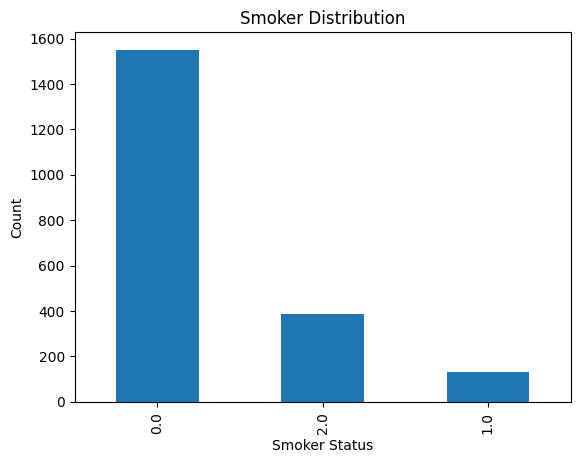

In [4289]:
df["smoker"].value_counts().plot(kind="bar")

plt.title("Smoker Distribution")
plt.xlabel("Smoker Status")
plt.ylabel("Count")

plt.show()

In [4290]:
print(df.isna().sum().sort_values(ascending= False).head(30))

unnamed:62                 2065
unnamed:61                 2044
failuredate                1964
signifcomp                 1706
minorcomp                  1659
cathremoval                1617
spcomplication             1008
fu                          176
ordate                       95
monthsurg                    93
cathdays                     47
earlycomps                   12
clavianii+                    5
datetofailureorfollowup       5
bmi35+                        4
diabetes                      4
copd                          4
open                          3
failure                       2
tissue                        2
charlsons                     2
penile                        2
patent                        1
urethroplasty                 1
spc                           1
#strictures                   1
urine                         1
age(attimeofsurgery)          1
prevprocedure                 1
distal                        1
dtype: int64


In [4291]:
df["clavianii+"].unique()

array([ 1.,  0., nan])

In [4292]:
df["clavianii+"]= df["clavianii+"].fillna(df["clavianii+"].median())
df["clavianii+"].unique()

array([1., 0.])

In [4293]:

df["diabetes"] = df["diabetes"].replace({"yes (no meds)": 1, "no ": 0})
df["diabetes"].unique()

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/2201697736.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["diabetes"] = df["diabetes"].replace({"yes (no meds)": 1, "no ": 0})


array([ 1.,  0., nan])

In [4294]:
df["diabetes"]= df["diabetes"].fillna(df["diabetes"].median())
df["diabetes"].unique()

/Users/preciousajilore/Documents/GitHub/torchmtlr/survivalenv/lib/python3.12/site-packages/IPython/core/displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


array([1., 0.])

In [4295]:
df["bmi35+"]= df["bmi35+"].fillna(df["bmi35+"].median())

df["bmi35+"].unique()

array([0., 1.])

In [4296]:

df["copd"].unique()

array([0, 1, 'no (Asthma)', 'no ', nan, 'on'], dtype=object)

In [4297]:
df["copd"] = df["copd"].replace({"no ": 0, "on": 0, "no (Asthma)": 0})
df["copd"].unique()


/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/3066313094.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["copd"] = df["copd"].replace({"no ": 0, "on": 0, "no (Asthma)": 0})


array([ 0.,  1., nan])

In [4298]:
df["copd"] = df["copd"].replace({"on": 0})
df["copd"].unique()


array([ 0.,  1., nan])

In [4299]:
df["copd"]= df["copd"].fillna(df["copd"].median())

df["copd"].unique()

array([0., 1.])

In [4300]:
df["open"] = df["open"].replace({"no ": 0, "Yes ": 1, "no": 0})

df["open"].unique()

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/2115308309.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["open"] = df["open"].replace({"no ": 0, "Yes ": 1, "no": 0})


array([ 0.,  1., nan])

In [4301]:
df["open"]= df["open"].fillna(df["open"].median())

df["open"].unique()

array([0., 1.])

In [4302]:
df["failure"]= df["failure"].fillna(df["failure"].median())

df["failure"].unique()

array([0., 1.])

In [4303]:
print(df.isna().sum().sort_values(ascending= False).head(30))

unnamed:62                 2065
unnamed:61                 2044
failuredate                1964
signifcomp                 1706
minorcomp                  1659
cathremoval                1617
spcomplication             1008
fu                          176
ordate                       95
monthsurg                    93
cathdays                     47
earlycomps                   12
datetofailureorfollowup       5
tissue                        2
charlsons                     2
penile                        2
urethroplasty                 1
urine                         1
spc                           1
prevprocedure                 1
patent                        1
#strictures                   1
stxlength                     1
stxetiology                   1
distal                        1
age(attimeofsurgery)          1
strictureintervention         0
satisfaction                  0
stricture                     0
incontinence                  0
dtype: int64


In [4304]:
""" 
array([1, 0, 2, 4, 3, 5, '1 (penobulbar only; not proximal bulbar)', nan],
      dtype=object)
"""
df["tissue"] = df["tissue"].replace({"1 (penobulbar only; not proximal bulbar)": 1})


df["tissue"].unique()

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/4267233135.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["tissue"] = df["tissue"].replace({"1 (penobulbar only; not proximal bulbar)": 1})


array([ 1.,  0.,  2.,  4.,  3.,  5., nan])

In [4305]:
df.columns

Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength',
       '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd',
       'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open',
       'ordate', 'urine', 'abx', 'erectilepre', 'uti', 'los(days)', 'spc',
       'tissue', 'transection', 'urethroplasty', 'cathremoval', 'cathdays',
       'failure', 'patent', 'fu', 'failuredate', 'datetofailureorfollowup',
       'complication', 'clavianii+', 'claviangrade', 'earlycomps',
       'signifcomp', 'minorcomp', 'ervisits', 'foley', 'spcomplication',
       'erectilepost', 'pain', 'chordee', 'pvd', 'donorsite', 'utipost',
       'utirecurring', 'luts', 'persistingluts', 'incontinence', 'stricture',
       'strictureintervention', 'satisfaction', 'unnamed:61', 'unnamed:62',
       'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0', 'claviangrade_0.0',
       'claviangrade_1.0',

In [4306]:
#Tissue Transfer 0=no, 1=yes BMG, 2= yes tunica dartos(vaginalis) flap, 3=yes combined graft/flap, 4= PIF, 5= other
tissue_dummies = pd.get_dummies(df["tissue"], prefix= "tissue", dummy_na= False)
df = pd.concat([df, tissue_dummies], axis=1)

In [4307]:
df["charlsons"]= df["charlsons"].fillna(df["charlsons"].median())

df["charlsons"].unique()

array([ 0.,  1.,  2.,  5.,  3.,  4.,  6.,  7., 11.])

In [4308]:
df["penile"]= df["penile"].fillna(df["penile"].median())

df["penile"].unique()

array([1., 0.])

In [4309]:
df["urethroplasty"]= df["urethroplasty"].fillna(df["urethroplasty"].median())

df["urethroplasty"].unique()


array([2., 4., 1., 5., 3., 6.])

In [4310]:
uro_dummies = pd.get_dummies(df["urethroplasty"], prefix= "urethroplasty", dummy_na= False)
df = pd.concat([df,uro_dummies], axis=1)
#Type of Urethroplasty (1=EPA anastomotic; 2=graft, BMG; 3=flap; 4=2stage/urethrostomy; 5=combined tissue ; 6=urethrostomy)

In [4311]:
df.columns

Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength',
       '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd',
       'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open',
       'ordate', 'urine', 'abx', 'erectilepre', 'uti', 'los(days)', 'spc',
       'tissue', 'transection', 'urethroplasty', 'cathremoval', 'cathdays',
       'failure', 'patent', 'fu', 'failuredate', 'datetofailureorfollowup',
       'complication', 'clavianii+', 'claviangrade', 'earlycomps',
       'signifcomp', 'minorcomp', 'ervisits', 'foley', 'spcomplication',
       'erectilepost', 'pain', 'chordee', 'pvd', 'donorsite', 'utipost',
       'utirecurring', 'luts', 'persistingluts', 'incontinence', 'stricture',
       'strictureintervention', 'satisfaction', 'unnamed:61', 'unnamed:62',
       'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0', 'claviangrade_0.0',
       'claviangrade_1.0',

In [4312]:
df["urine"].unique()


array([0, 1, 'no record', nan], dtype=object)

In [4313]:
df["urine"] = df["urine"].replace({"no record": np.nan})

df["urine"] = df["urine"].fillna(df["urine"].median())
df["urine"].unique()



/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/3819477032.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["urine"] = df["urine"].replace({"no record": np.nan})


array([0., 1.])

In [4314]:
df["spc"] = df["spc"].fillna(df["spc"].median())
df["spc"].unique()


array([0., 1.])

In [4315]:
df["prevprocedure"] = df["prevprocedure"].fillna(df["prevprocedure"].median())
df["prevprocedure"].unique()

array([1., 0.])

In [4316]:
df["#strictures"] = df["#strictures"].fillna(df["#strictures"].median())

df["#strictures"].unique()

array([1., 2., 0.])

In [4317]:
#stricture location
df["stxlocation"].unique()

array([0, 2, 1, 3, 4, 5, '0 and 1', '1 and 4', 6, 'urethral cancer',
       '0, 1'], dtype=object)

In [4318]:
def clean_stx(val):
    if pd.isna(val):
        return np.nan
    
    v = str(val).lower().strip()

    if "cancer" in v:
        return np.nan
    
    v = v.replace("and", ",").replace(" ", "")

    return v

In [4319]:
df["stxlocationclean"] = df["stxlocation"].apply(clean_stx)
df["stxlocationclean"].unique()


array(['0', '2', '1', '3', '4', '5', '0,1', '1,4', '6', nan], dtype=object)

In [4320]:
stx_dummies = df["stxlocationclean"].str.get_dummies(sep=",")


In [4321]:
df = pd.concat([df, stx_dummies.add_prefix("stxlocation_")], axis=1)


In [4322]:
df.columns

Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength',
       '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd',
       'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open',
       'ordate', 'urine', 'abx', 'erectilepre', 'uti', 'los(days)', 'spc',
       'tissue', 'transection', 'urethroplasty', 'cathremoval', 'cathdays',
       'failure', 'patent', 'fu', 'failuredate', 'datetofailureorfollowup',
       'complication', 'clavianii+', 'claviangrade', 'earlycomps',
       'signifcomp', 'minorcomp', 'ervisits', 'foley', 'spcomplication',
       'erectilepost', 'pain', 'chordee', 'pvd', 'donorsite', 'utipost',
       'utirecurring', 'luts', 'persistingluts', 'incontinence', 'stricture',
       'strictureintervention', 'satisfaction', 'unnamed:61', 'unnamed:62',
       'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0', 'claviangrade_0.0',
       'claviangrade_1.0',

In [4323]:
df["stxlength"].unique()

array([3.5, 5, 3, 6.5, 1, 1.5, 2, 5.5, 6, 4, 2.5, 15, 12, 16, 11, 9, 7,
       18, 4.5, 10, 20, 8, 22, 14, 13, 19, 7.5, 17, 12.5, 21, '4.5',
       '6.5', '3.5', '0.5', '2.5', '4 bulbar and 2 penile', 8.5, nan,
       '5.5', '1, 5', '2,1'], dtype=object)

In [4324]:
# 1) Find all numbers (including decimals) in each entry
num_lists = df["stxlength"].astype(str).str.findall(r"\d+\.?\d*")

# 2) First length (or 0 if none)
df["stx_length_1"] = num_lists.apply(lambda x: float(x[0]) if len(x) > 0 else 0)

# 3) Second length (or 0 if there isn’t one)
df["stx_length_2"] = num_lists.apply(lambda x: float(x[1]) if len(x) > 1 else 0)

In [4325]:
print(df[["stxlength","stx_length_1","stx_length_2"]].head(10))

# 2) Check dtypes
print(df[["stx_length_1","stx_length_2"]].dtypes)

  stxlength  stx_length_1  stx_length_2
0       3.5           3.5           0.0
1         5           5.0           0.0
2         3           3.0           0.0
3       6.5           6.5           0.0
4         1           1.0           0.0
5       1.5           1.5           0.0
6         2           2.0           0.0
7         5           5.0           0.0
8         5           5.0           0.0
9         5           5.0           0.0
stx_length_1    float64
stx_length_2    float64
dtype: object


In [4326]:
df["stxetiology"].unique()

array([2, 4, 1, 0, 5, 3, 6, '2,4', nan, 'priapism',
       '5- this stricture (his newer stricture) happened after the last surgery .. so would it be iatrogenic?'],
      dtype=object)

In [4327]:
#StxEtiology(0=idio, 1=trauma, 2=bxo/ls, 3= radiation (EBRT/BT), 4=hypospadias, 5=iatrogenic, 6=inflammatory/infectious
#array([2, 4, 1, 0, 5, 3, 6, '2,4', nan, 'priapism',
      # '5- this stricture (his newer stricture) happened after the last surgery .. so would it be iatrogenic?'],
     # dtype=object)
df["stxetiology"]= df["stxetiology"].replace({"priapism": np.nan, '5- this stricture (his newer stricture) happened after the last surgery .. so would it be iatrogenic?': 5})
df["stxetiology"].unique()

array([2, 4, 1, 0, 5, 3, 6, '2,4', nan], dtype=object)

In [4328]:

df["stxetiologyclean"] = (
    df["stxetiology"]                   # original column
      .astype(str)                      # make everything a string
      .str.replace(" ", "")             # drop any spaces
      .replace("nan", "")               # turn literal "nan" → empty
)

# 2) One-hot encode on the commas
etiology_dummies = (
    df["stxetiologyclean"]
      .str.get_dummies(sep=",")         # splits "2,4" → cols 2 & 4
      .rename(columns=lambda x: f"stxetiology_{x}")
)

# 3) Glue back on
df = pd.concat([df, etiology_dummies], axis=1)

In [4329]:
mask = df["stxetiology"].astype(str).str.contains("2,4")
df.loc[mask, ["stxetiology", "stxetiology_2", "stxetiology_4"]]

,stxetiology,stxetiology_2,stxetiology_4
1743,"2,4",1,1


In [4330]:
df["distal"]=df["distal"].replace({11:1})
df["distal"].unique()

array([ 0.,  1., nan])

In [4331]:
df["distal"]= df["distal"].fillna(df["distal"].median())
df["distal"].unique()

array([0., 1.])

In [4332]:
print(df.isna().sum().sort_values(ascending= False).head(30))

unnamed:62                 2065
unnamed:61                 2044
failuredate                1964
signifcomp                 1706
minorcomp                  1659
cathremoval                1617
spcomplication             1008
fu                          176
ordate                       95
monthsurg                    93
cathdays                     47
earlycomps                   12
datetofailureorfollowup       5
stxetiology                   2
tissue                        2
age(attimeofsurgery)          1
patent                        1
stxlength                     1
stxlocationclean              1
claviangrade_5.0              0
claviangrade_2.0              0
claviangrade_0.0              0
tissue_4.0                    0
tissue_3.0                    0
claviangrade_1.0              0
tissue_2.0                    0
claviangrade_6.0              0
tissue_1.0                    0
claviangrade_3.0              0
tissue_0.0                    0
dtype: int64


In [4333]:
df["earlycomps"].unique()

array([0, 2, 1, 'No', nan], dtype=object)

In [4334]:
df["earlycomps"]=df["earlycomps"].replace({"No": 0})
df["earlycomps"]= df["earlycomps"].fillna(df["earlycomps"].median())

df["earlycomps"].unique()

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_603/2952953434.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["earlycomps"]=df["earlycomps"].replace({"No": 0})


array([0., 2., 1.])

In [4335]:
df.shape

(2066, 107)

In [4336]:
print(df.isna().sum().sort_values(ascending= False).head(30))

unnamed:62                 2065
unnamed:61                 2044
failuredate                1964
signifcomp                 1706
minorcomp                  1659
cathremoval                1617
spcomplication             1008
fu                          176
ordate                       95
monthsurg                    93
cathdays                     47
datetofailureorfollowup       5
stxetiology                   2
tissue                        2
age(attimeofsurgery)          1
patent                        1
stxlength                     1
stxlocationclean              1
claviangrade_3.0              0
tissue_1.0                    0
cysto_3.0                     0
tissue_4.0                    0
tissue_3.0                    0
tissue_2.0                    0
claviangrade_0.0              0
tissue_0.0                    0
claviangrade_4.0              0
claviangrade_1.0              0
erectilepost_4.0              0
claviangrade_2.0              0
dtype: int64


In [4337]:
num_failures = (df["failure"] == 1).sum()
print(num_failures)

180


In [4338]:
# 1) Make sure both dates are real datetimes
df["dateofsurgery"] = pd.to_datetime(df["dateofsurgery"], errors="coerce")
df["fu"]            = pd.to_datetime(df["fu"],            errors="coerce")


In [4339]:
study_end = df["fu"].max()

df["fu_imputed"] = df["fu"].fillna(study_end)

df["time_to_event"] = (df["fu_imputed"] - df["dateofsurgery"]).dt.days.clip(lower=0)


In [4340]:
print(df["time_to_event"].describe())

count    2066.000000
mean      811.764763
std      1233.466639
min         0.000000
25%       157.000000
50%       393.000000
75%       811.750000
max      7949.000000
Name: time_to_event, dtype: float64


In [4341]:
df["cathdays"] = df["cathdays"].replace({np.nan: 28})
df["cathdays"].isna().sum()

0

In [4342]:
df["signifcomp"].unique()

array([0, nan, 7, 2, 1, '3 + 4', 6, 4, '1 + 2', ' n/a', 'Lost to fu',
       '0 + 3', 3, 'N/a'], dtype=object)

In [4343]:
df["signifcomp"]= df["signifcomp"].replace({"N/a": 0, " n/a": 0, np.nan: 0, 0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7, 7:8 , "Lost to fu": 0})
df["signifcomp"].unique()

array([1, 0, 8, 3, 2, '3 + 4', 7, 5, '1 + 2', '0 + 3', 4], dtype=object)

In [4344]:
newcol = df['signifcomp'].astype(str).str.replace(' ', '')

In [4345]:
one_hot = newcol.str.get_dummies(sep='+')
one_hot = one_hot.add_prefix("signifcomp")
df = df.join(one_hot)
df.columns


Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength',
       '#strictures',
       ...
       'fu_imputed', 'time_to_event', 'signifcomp0', 'signifcomp1',
       'signifcomp2', 'signifcomp3', 'signifcomp4', 'signifcomp5',
       'signifcomp7', 'signifcomp8'],
      dtype='object', length=117)

In [4346]:
df["minorcomp"].unique()

array([4, nan, 0, 1, 2, '1(failed TOV)', 3, '3,0', '3, 0', '0,2',
       '3 (Pain control)', '0+3', '0+2',
       'no perioperative comp, but persistant luts', '3 (drained abcess)',
       '???', 'no FU', 'required dilation', 'lost to f/u', '0, 1'],
      dtype=object)

In [4347]:
df["minorcomp"] = df["minorcomp"].replace({0:1, 1:2, 2:3, 4:5, np.nan: 0})
df["minorcomp"].unique()

array([5, 0, 1, 2, 3, '1(failed TOV)', '3,0', '3, 0', '0,2',
       '3 (Pain control)', '0+3', '0+2',
       'no perioperative comp, but persistant luts', '3 (drained abcess)',
       '???', 'no FU', 'required dilation', 'lost to f/u', '0, 1'],
      dtype=object)

In [4348]:
df["minorcomp"] = df["minorcomp"].replace({"???": 0})
df["minorcomp"].unique()


array([5, 0, 1, 2, 3, '1(failed TOV)', '3,0', '3, 0', '0,2',
       '3 (Pain control)', '0+3', '0+2',
       'no perioperative comp, but persistant luts', '3 (drained abcess)',
       'no FU', 'required dilation', 'lost to f/u', '0, 1'], dtype=object)

In [4349]:
# your mapping
bump = {2: 3,
         3: 4}

def bump_codes(x):
    if pd.isna(x):
        return x
    # if it’s already a pure number
    if isinstance(x, (int, float)) and not isinstance(x, bool):
        return bump.get(x, x)
    s = str(x)
    # replace each integer token according to bump, else keep it
    return re.sub(
        r"\b\d+\b",
        lambda m: str(bump.get(int(m.group()), int(m.group()))),
        s
    )

# apply to your column
df["minorcomp"] = df["minorcomp"].apply(bump_codes)

# quick check
print(df["minorcomp"].unique())

[5 0 1 3 4 '1(failed TOV)' '4,0' '4, 0' '0,3' '4 (Pain control)' '0+4'
 '0+3' 'no perioperative comp, but persistant luts' '4 (drained abcess)'
 'no FU' 'required dilation' 'lost to f/u' '0, 1']


In [4350]:
df["minorcomp"] = df["minorcomp"].replace({"no perioperative comp, but persistant luts": 0, "1(failed TOV)":1, "4 (drained abcess)": 4, "4 (Pain control)": 4, 'required dilation': 3, "lost to f/u": 0,"no FU": 0})
df["minorcomp"].unique()

array([5, 0, 1, 3, 4, '4,0', '4, 0', '0,3', '0+4', '0+3', '0, 1'],
      dtype=object)

In [4351]:
clean = (
    df['minorcomp']
      .astype(str)
      .str.replace(r'\s*[,+]\s*', '+', regex=True)
)

print(clean.unique())

['5' '0' '1' '3' '4' '4+0' '0+3' '0+4' '0+1']


In [4352]:
one = (
    clean.str.get_dummies(sep="+")
    .add_prefix("minorcomp")
)
df= df.join(one)
df.columns


Index(['dob(yyyy-mm-dd)', 'dateofsurgery', 'monthsurg', 'age(attimeofsurgery)',
       'stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength',
       '#strictures',
       ...
       'signifcomp3', 'signifcomp4', 'signifcomp5', 'signifcomp7',
       'signifcomp8', 'minorcomp0', 'minorcomp1', 'minorcomp3', 'minorcomp4',
       'minorcomp5'],
      dtype='object', length=122)

In [4353]:
print(df.isna().sum().sort_values(ascending= False).head(30))

unnamed:62                 2065
unnamed:61                 2044
failuredate                1964
cathremoval                1617
spcomplication             1008
fu                          179
ordate                       95
monthsurg                    93
datetofailureorfollowup       5
stxetiology                   2
tissue                        2
patent                        1
age(attimeofsurgery)          1
stxlocationclean              1
stxlength                     1
urethroplasty_5.0             0
urethroplasty_4.0             0
stxlocation_0                 0
urethroplasty_6.0             0
urethroplasty_2.0             0
stxlocation_1                 0
stxlocation_2                 0
urethroplasty_3.0             0
tissue_4.0                    0
urethroplasty_1.0             0
tissue_5.0                    0
stxlocation_4                 0
tissue_3.0                    0
tissue_2.0                    0
tissue_1.0                    0
dtype: int64


In [4354]:
df_failure = df[df["failure"] == 1].copy()

df_failure.to_csv("failures.csv", index= False)

SEGMENTING

In [4355]:
#Load the dictionary
dictionary = pd.read_csv("/Users/preciousajilore/Documents/GitHub/torchmtlr/data/featuredictionary_new.csv")

dictionary.columns = [col.strip() for col in dictionary.columns]
dictionary.columns

Index(['FEATURE DICTIONARY', 'abbreviated name', 'full name',
       'feature category', 'one-hot/multi-coding', 'Unnamed: 5'],
      dtype='object')

In [4363]:
#Get a list of features considered as "before surgery"
before_surgery = dictionary.loc[dictionary['feature category'].str.strip().str.lower() == 'before surgery', 'abbreviated name'].tolist()
for i, feature in enumerate(before_surgery):
    before_surgery[i] = feature.lower().strip().replace(" ","")

new_before =[
 
            'stx_length_1',
             'stx_length_2',
             'stxetiology_0',
             'stxetiology_1', 
             'stxetiology_2', 
             'stxetiology_3', 
             'stxetiology_4',
             'stxetiology_5', 
             'stxetiology_6',
             'stxlocation_0',
             'stxlocation_1',
             'stxlocation_2',
             'stxlocation_3',
             'stxlocation_4',
             'stxlocation_5',
             'stxlocation_6',
             'stx_length_1',
             'stx_length_2',
             'cysto_0.0',
             'cysto_1.0',
             'cysto_2.0',
             'cysto_3.0',
             
]

for feature in new_before:
   before_surgery.append(feature)

before_surgery.remove("bmiexact")
print(before_surgery)

#Get a list of features considered to be "immediately before surgery"
imm_bf_surgery = dictionary.loc[dictionary['feature category'].str.strip().str.lower() == 'immediately before surgery', 'abbreviated name'].tolist()
for i, feature in enumerate(imm_bf_surgery):
    imm_bf_surgery[i] = feature.lower().strip().replace(" ","")

print(imm_bf_surgery)

#Get a list of features considered to be "immediately after surgery"
imm_aft_surgery = dictionary.loc[dictionary['feature category'].str.strip().str.lower() == 'immediately after surgery',"abbreviated name"].tolist()

for i, feature in enumerate(imm_aft_surgery):
    imm_aft_surgery[i] = feature.lower().strip().replace(" ","")


new_aft = ['tissue_0.0',
 'tissue_1.0',
 'tissue_2.0',
 'tissue_3.0',
 'tissue_4.0',
 'tissue_5.0',
 'urethroplasty_1.0',
 'urethroplasty_2.0',
 'urethroplasty_3.0',
 'urethroplasty_4.0',
 'urethroplasty_5.0',
 'urethroplasty_6.0',]


for feature in new_aft:
  imm_aft_surgery.append(feature)


print(imm_aft_surgery)

['stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd', 'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'stx_length_1', 'stx_length_2', 'stxetiology_0', 'stxetiology_1', 'stxetiology_2', 'stxetiology_3', 'stxetiology_4', 'stxetiology_5', 'stxetiology_6', 'stxlocation_0', 'stxlocation_1', 'stxlocation_2', 'stxlocation_3', 'stxlocation_4', 'stxlocation_5', 'stxlocation_6', 'stx_length_1', 'stx_length_2', 'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0']
['abx', 'erectilepre', 'uti']
['los(days)', 'spc', 'tissue', 'transection', 'urethroplasty', 'cathremoval', 'cathdays', 'tissue_0.0', 'tissue_1.0', 'tissue_2.0', 'tissue_3.0', 'tissue_4.0', 'tissue_5.0', 'urethroplasty_1.0', 'urethroplasty_2.0', 'urethroplasty_3.0', 'urethroplasty_4.0', 'urethroplasty_5.0', 'urethroplasty_6.0']


In [4361]:
df.columns.to_list()

['dob(yyyy-mm-dd)',
 'dateofsurgery',
 'monthsurg',
 'age(attimeofsurgery)',
 'stxlocation',
 'distal',
 'penile',
 'stxetiology',
 'stxlength',
 '#strictures',
 'charlsons',
 'cormorbidity',
 'diabetes',
 'copd',
 'smoker',
 'bmi35+',
 'prevprocedure',
 '#prevprocedures',
 'cysto',
 'open',
 'ordate',
 'urine',
 'abx',
 'erectilepre',
 'uti',
 'los(days)',
 'spc',
 'tissue',
 'transection',
 'urethroplasty',
 'cathremoval',
 'cathdays',
 'failure',
 'patent',
 'fu',
 'failuredate',
 'datetofailureorfollowup',
 'complication',
 'clavianii+',
 'claviangrade',
 'earlycomps',
 'signifcomp',
 'minorcomp',
 'ervisits',
 'foley',
 'spcomplication',
 'erectilepost',
 'pain',
 'chordee',
 'pvd',
 'donorsite',
 'utipost',
 'utirecurring',
 'luts',
 'persistingluts',
 'incontinence',
 'stricture',
 'strictureintervention',
 'satisfaction',
 'unnamed:61',
 'unnamed:62',
 'cysto_0.0',
 'cysto_1.0',
 'cysto_2.0',
 'cysto_3.0',
 'claviangrade_0.0',
 'claviangrade_1.0',
 'claviangrade_2.0',
 'clavian

In [4365]:


combined_before = before_surgery + imm_bf_surgery
df_preop = df[combined_before].copy()

combined_after = before_surgery + imm_bf_surgery + imm_aft_surgery  
df_imm_af = df[combined_after].copy()

print("Pre‐op shape:",         df_preop.shape)
print("Pre+Post‐op shape:",    df_imm_af.shape)
print("Pre‐op columns:",       df_preop.columns.tolist())
print("Pre+Post‐op columns:",  df_imm_af.columns.tolist())

Pre‐op shape: (2066, 43)
Pre+Post‐op shape: (2066, 62)
Pre‐op columns: ['stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd', 'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'stx_length_1', 'stx_length_2', 'stxetiology_0', 'stxetiology_1', 'stxetiology_2', 'stxetiology_3', 'stxetiology_4', 'stxetiology_5', 'stxetiology_6', 'stxlocation_0', 'stxlocation_1', 'stxlocation_2', 'stxlocation_3', 'stxlocation_4', 'stxlocation_5', 'stxlocation_6', 'stx_length_1', 'stx_length_2', 'cysto_0.0', 'cysto_1.0', 'cysto_2.0', 'cysto_3.0', 'abx', 'erectilepre', 'uti']
Pre+Post‐op columns: ['stxlocation', 'distal', 'penile', 'stxetiology', 'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes', 'copd', 'smoker', 'bmi35+', 'prevprocedure', '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'stx_length_1', 'stx_length_2', 'stxetiology_0', 'stxetiology_1', 'stxetiology_2', 's

In [4366]:
df_preop.to_csv("preop.csv", index= False)
df_imm_af.to_csv("prepostop.csv", index= False)